### The 3 Steps of a Groupby Process

Any groupby process involves some combination of the following 3 steps:

Splitting the original object into groups based on the defined criteria.
Applying a function to each group.
Combining the results.

### Below digram is showing split-apply-combine method. Use of mean in apply step

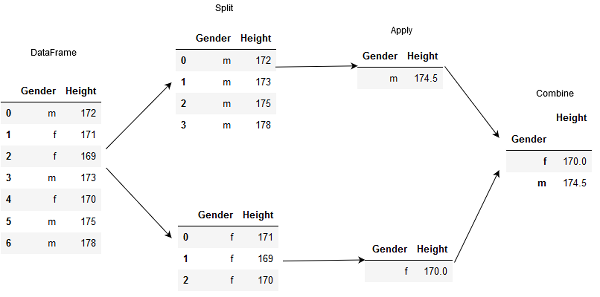

In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv("complete.csv")

In [6]:
df

,awardYear,category,categoryFullName,sortOrder,portion,prizeAmount,prizeAmountAdjusted,dateAwarded,prizeStatus,motivation,...,org_founded_country,org_founded_countryNow,org_founded_locationString,ind_or_org,residence_1,residence_2,affiliation_1,affiliation_2,affiliation_3,affiliation_4
0,2001,Economic Sciences,The Sveriges Riksbank Prize in Economic Scienc...,2,1/3,10000000,12295082,2001-10-10,received,for their analyses of markets with asymmetric ...,...,NaN,NaN,NaN,Individual,NaN,NaN,"Stanford University, Stanford, CA, USA",NaN,NaN,NaN
1,1975,Physics,The Nobel Prize in Physics,1,1/3,630000,3404179,1975-10-17,received,for the discovery of the connection between co...,...,NaN,NaN,NaN,Individual,NaN,NaN,"Niels Bohr Institute, Copenhagen, Denmark",NaN,NaN,NaN
2,2004,Chemistry,The Nobel Prize in Chemistry,1,1/3,10000000,11762861,2004-10-06,received,for the discovery of ubiquitin-mediated protei...,...,NaN,NaN,NaN,Individual,NaN,NaN,"Technion - Israel Institute of Technology, Hai...",NaN,NaN,NaN
3,1982,Chemistry,The Nobel Prize in Chemistry,1,1,1150000,3102518,1982-10-18,received,for his development of crystallographic electr...,...,NaN,NaN,NaN,Individual,NaN,NaN,"MRC Laboratory of Molecular Biology, Cambridge...",NaN,NaN,NaN
4,1979,Physics,The Nobel Prize in Physics,2,1/3,800000,2988048,1979-10-15,received,for their contributions to the theory of the u...,...,NaN,NaN,NaN,Individual,NaN,NaN,"International Centre for Theoretical Physics, ...","Imperial College, London, United Kingdom",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,1972,Physics,The Nobel Prize in Physics,1,1/3,480000,3345725,NaN,received,for their jointly developed theory of supercon...,...,NaN,NaN,NaN,Individual,NaN,NaN,"University of Illinois, Urbana, IL, USA",NaN,NaN,NaN
946,1954,Chemistry,The Nobel Prize in Chemistry,1,1,181647,2640218,NaN,received,for his research into the nature of the chemic...,...,NaN,NaN,NaN,Individual,NaN,NaN,"California Institute of Technology (Caltech), ...",NaN,NaN,NaN
947,1911,Chemistry,The Nobel Prize in Chemistry,1,1,140695,7327865,NaN,received,in recognition of her services to the advancem...,...,NaN,NaN,NaN,Individual,NaN,NaN,"Sorbonne University, Paris, France",NaN,NaN,NaN
948,1981,Peace,The Nobel Peace Prize,1,1,1000000,2929688,1981-10-14,received,for promoting the fundamental rights of refugees,...,Switzerland,Switzerland,"Geneva, Switzerland",Organization,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.columns.tolist()

['awardYear',
 'category',
 'categoryFullName',
 'sortOrder',
 'portion',
 'prizeAmount',
 'prizeAmountAdjusted',
 'dateAwarded',
 'prizeStatus',
 'motivation',
 'categoryTopMotivation',
 'award_link',
 'id',
 'name',
 'knownName',
 'givenName',
 'familyName',
 'fullName',
 'penName',
 'gender',
 'laureate_link',
 'birth_date',
 'birth_city',
 'birth_cityNow',
 'birth_continent',
 'birth_country',
 'birth_countryNow',
 'birth_locationString',
 'death_date',
 'death_city',
 'death_cityNow',
 'death_continent',
 'death_country',
 'death_countryNow',
 'death_locationString',
 'orgName',
 'nativeName',
 'acronym',
 'org_founded_date',
 'org_founded_city',
 'org_founded_cityNow',
 'org_founded_continent',
 'org_founded_country',
 'org_founded_countryNow',
 'org_founded_locationString',
 'ind_or_org',
 'residence_1',
 'residence_2',
 'affiliation_1',
 'affiliation_2',
 'affiliation_3',
 'affiliation_4']

In [8]:
len(df.columns)

52

In [9]:
df = df[['awardYear', 'category', 'prizeAmount', 'prizeAmountAdjusted', 'name', 'gender', 'birth_continent']]

In [11]:
df

,awardYear,category,prizeAmount,prizeAmountAdjusted,name,gender,birth_continent
0,2001,Economic Sciences,10000000,12295082,A. Michael Spence,male,North America
1,1975,Physics,630000,3404179,Aage N. Bohr,male,Europe
2,2004,Chemistry,10000000,11762861,Aaron Ciechanover,male,Asia
3,1982,Chemistry,1150000,3102518,Aaron Klug,male,Europe
4,1979,Physics,800000,2988048,Abdus Salam,male,Asia
...,...,...,...,...,...,...,...
945,1972,Physics,480000,3345725,John Bardeen,male,North America
946,1954,Chemistry,181647,2640218,Linus Pauling,male,North America
947,1911,Chemistry,140695,7327865,Marie Curie,female,Europe
948,1981,Peace,1000000,2929688,Office of the United Nations High Commissioner...,NaN,NaN


### Splitting the Original Object into Groups

At this stage, we call the pandas DataFrame.groupby() function. We use it to split the data into groups based on predefined criteria, along rows (by default, axis=0), or columns (axis=1). In other words, this function maps the labels to the names of the groups.

For example, in our case, we can group the data on Nobel prizes by prize category:

In [19]:
grouped = df.groupby('category')

In [21]:
grouped

It is also possible to use more than one column to perform data grouping, passing a list of columns. Let's group our data first by prize category and then, inside each of the created groups, we will apply additional grouping based on the year of the prize award:

In [24]:
grouped_category_year = df.groupby(['category', 'awardYear'])

In [26]:
grouped_category_year

It is important to note that creating a GroupBy object only checks if we have passed a correct mapping; it doesn't really perform any of the operations of the split-apply-combine chain until we explicitly use some method on this object or extract some of its attributes.

To briefly inspect the resulting GroupBy object and check how exactly the groups were split, we can extract from it the groups or indices attribute. Both of them return a dictionary where the keys are the created groups and the values are the lists of axis labels (for the groups attribute) or indices (for the indices attribute) of the instances of each group in the original DataFrame:

In [ ]:
df[df.category=='Economic Sciences']

In [12]:
grouped.groups

{'Chemistry': [2, 3, 7, 9, 10, 11, 13, 14, 15, 17, 19, 39, 62, 64, 66, 71, 75, 80, 81, 86, 92, 104, 107, 112, 129, 135, 153, 169, 175, 178, 181, 188, 197, 199, 203, 210, 215, 223, 227, 239, 247, 249, 258, 264, 265, 268, 272, 274, 280, 282, 284, 289, 296, 298, 310, 311, 317, 318, 337, 341, 343, 348, 352, 357, 362, 365, 366, 372, 374, 384, 394, 395, 396, 415, 416, 419, 434, 440, 442, 444, 446, 448, 450, 455, 456, 459, 461, 463, 465, 469, 475, 504, 505, 508, 518, 522, 523, 524, 539, 549, ...], 'Economic Sciences': [0, 5, 45, 46, 58, 90, 96, 139, 140, 145, 152, 156, 157, 180, 187, 193, 207, 219, 231, 232, 246, 250, 269, 279, 283, 295, 305, 324, 346, 369, 418, 422, 425, 426, 430, 432, 438, 458, 467, 476, 485, 510, 525, 527, 537, 538, 546, 580, 594, 595, 605, 611, 636, 637, 657, 669, 670, 678, 700, 708, 716, 724, 734, 737, 739, 745, 747, 749, 750, 753, 758, 767, 800, 805, 854, 856, 860, 864, 871, 882, 896, 912, 916, 924], 'Literature': [21, 31, 40, 49, 52, 98, 100, 101, 102, 111, 115, 142, 1

### OR

In [13]:
grouped.indices

{'Chemistry': array([  2,   3,   7,   9,  10,  11,  13,  14,  15,  17,  19,  39,  62,
         64,  66,  71,  75,  80,  81,  86,  92, 104, 107, 112, 129, 135,
        153, 169, 175, 178, 181, 188, 197, 199, 203, 210, 215, 223, 227,
        239, 247, 249, 258, 264, 265, 268, 272, 274, 280, 282, 284, 289,
        296, 298, 310, 311, 317, 318, 337, 341, 343, 348, 352, 357, 362,
        365, 366, 372, 374, 384, 394, 395, 396, 415, 416, 419, 434, 440,
        442, 444, 446, 448, 450, 455, 456, 459, 461, 463, 465, 469, 475,
        504, 505, 508, 518, 522, 523, 524, 539, 549, 558, 559, 563, 567,
        571, 572, 585, 591, 596, 599, 627, 630, 632, 641, 643, 644, 648,
        659, 661, 666, 667, 668, 671, 673, 679, 681, 686, 713, 715, 717,
        719, 720, 722, 723, 725, 726, 729, 732, 738, 742, 744, 746, 751,
        756, 759, 763, 766, 773, 776, 798, 810, 813, 814, 817, 827, 828,
        829, 832, 839, 848, 853, 855, 862, 866, 880, 885, 886, 888, 889,
        892, 894, 897, 902, 904, 914, 

To find the number of groups in a GroupBy object, we can extract from it the ngroups attribute or call the len function of the Python standard library:

In [14]:
len(grouped)

6

In [15]:
grouped.ngroups

6

If instead, we want to select a single group in a form of DataFrame, we should use the method get_group() on the GroupBy object:

In [16]:
grouped.get_group('Economic Sciences')

,awardYear,category,prizeAmount,prizeAmountAdjusted,name,gender,birth_continent
0,2001,Economic Sciences,10000000,12295082,A. Michael Spence,male,North America
5,2019,Economic Sciences,9000000,9000000,Abhijit Banerjee,male,Asia
45,2012,Economic Sciences,8000000,8361204,Alvin E. Roth,male,North America
46,1998,Economic Sciences,7600000,9713701,Amartya Sen,male,Asia
58,2015,Economic Sciences,8000000,8384572,Angus Deaton,male,Europe
...,...,...,...,...,...,...,...
882,2002,Economic Sciences,10000000,12034660,Vernon L. Smith,male,North America
896,1973,Economic Sciences,510000,3331882,Wassily Leontief,male,Europe
912,2018,Economic Sciences,9000000,9000000,William D. Nordhaus,male,North America
916,1990,Economic Sciences,4000000,6329114,William F. Sharpe,male,North America


In [18]:
df.category.unique()

array(['Economic Sciences', 'Physics', 'Chemistry', 'Peace',
       'Physiology or Medicine', 'Literature'], dtype=object)

In [34]:
grouped.get_group(['Economic Sciences', 'Physics'])

TypeError: unhashable type: 'list'

In [17]:
df.head()

,awardYear,category,prizeAmount,prizeAmountAdjusted,name,gender,birth_continent
0,2001,Economic Sciences,10000000,12295082,A. Michael Spence,male,North America
1,1975,Physics,630000,3404179,Aage N. Bohr,male,Europe
2,2004,Chemistry,10000000,11762861,Aaron Ciechanover,male,Asia
3,1982,Chemistry,1150000,3102518,Aaron Klug,male,Europe
4,1979,Physics,800000,2988048,Abdus Salam,male,Asia


### Applying a Function by Group

After splitting the original data and (optionally) inspecting the resulting groups, we can perform one of the following operations or their combination (not necessarily in the given order) on each group:

Aggregation: calculating a summary statistic for each group (e.g., group sizes, means, medians, or sums) and outputting a single number for many data points.

Transformation: conducting some operations by group, such as calculating the z-score for each group.

Filtration: rejecting some groups based on a predefined condition, such as group size, mean, median, or sum. This can also include filtering out particular rows from each group.

#### Aggregation
To aggregate the data of a GroupBy object (i.e., to calculate a summary statistic by group), we can use the agg() method on the object:

In [17]:
grouped.agg(np.mean)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_12080\1243003623.py:1: FutureWarning: The operation <function mean at 0x000001AF729CC400> failed on a column. If any error is raised, this will raise an exception in a future version of pandas. Drop these columns to avoid this warning.
  grouped.agg(np.mean)


,awardYear,prizeAmount,prizeAmountAdjusted
category,,,
Chemistry,1972.347826,3.629279e+06,6.257868e+06
Economic Sciences,1996.119048,6.105845e+06,7.837779e+06
Literature,1960.931034,2.493811e+06,5.598256e+06
Peace,1964.537313,3.124879e+06,6.163907e+06
Physics,1971.065728,3.407939e+06,6.086978e+06
Physiology or Medicine,1970.356164,3.072973e+06,5.738301e+06


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   awardYear            950 non-null    int64 
 1   category             950 non-null    object
 2   prizeAmount          950 non-null    int64 
 3   prizeAmountAdjusted  950 non-null    int64 
 4   name                 950 non-null    object
 5   gender               923 non-null    object
 6   birth_continent      923 non-null    object
dtypes: int64(3), object(4)
memory usage: 52.1+ KB


In [19]:
df.columns.tolist()

['awardYear',
 'category',
 'prizeAmount',
 'prizeAmountAdjusted',
 'name',
 'gender',
 'birth_continent']

In [20]:
#If we need to aggregate data for two or more columns, we use double square brackets:

grouped[['prizeAmount', 'prizeAmountAdjusted']].agg(np.mean)

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,3.629279e+06,6.257868e+06
Economic Sciences,6.105845e+06,7.837779e+06
Literature,2.493811e+06,5.598256e+06
Peace,3.124879e+06,6.163907e+06
Physics,3.407939e+06,6.086978e+06
Physiology or Medicine,3.072973e+06,5.738301e+06


In [21]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].agg(np.median)

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,800000.0,5117217.0
Economic Sciences,7550000.0,9000000.0
Literature,269000.0,4366629.0
Peace,480000.0,5238085.0
Physics,700000.0,4907955.0
Physiology or Medicine,510000.0,4098361.0


In [22]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].agg(np.max)

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,10000000,12295082
Economic Sciences,10000000,12295082
Literature,10000000,12295082
Peace,10000000,12295082
Physics,10000000,12295082
Physiology or Medicine,10000000,12295082


In [23]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].agg(np.min)

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,114935,2394643
Economic Sciences,375000,2889667
Literature,114935,2377268
Peace,116960,2377268
Physics,114935,2377268
Physiology or Medicine,114935,2377268


In [24]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].agg(np.sum)

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,667787418,1151447726
Economic Sciences,512891000,658373449
Literature,289282102,649397731
Peace,418733807,825963521
Physics,725890928,1296526352
Physiology or Medicine,672981066,1256687857


In [25]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].agg(np.size)

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,184,184
Economic Sciences,84,84
Literature,116,116
Peace,134,134
Physics,213,213
Physiology or Medicine,219,219


In [26]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].agg(np.std)

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,4.070588e+06,3.276027e+06
Economic Sciences,3.787630e+06,3.313153e+06
Literature,3.653734e+06,3.029512e+06
Peace,3.934391e+06,3.189886e+06
Physics,4.013073e+06,3.294268e+06
Physiology or Medicine,3.898539e+06,3.241781e+06


Instead of using the agg() method, we can apply the corresponding pandas method directly on a GroupBy object. The most common methods are mean(), median(), mode(), sum(), size(), count(), min(), max(), std(), var() 

In [27]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].count()

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,184,184
Economic Sciences,84,84
Literature,116,116
Peace,134,134
Physics,213,213
Physiology or Medicine,219,219


In [28]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].sum()

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,667787418,1151447726
Economic Sciences,512891000,658373449
Literature,289282102,649397731
Peace,418733807,825963521
Physics,725890928,1296526352
Physiology or Medicine,672981066,1256687857


In [29]:
df.groupby('category').sum()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_12080\1847462723.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby('category').sum()


,awardYear,prizeAmount,prizeAmountAdjusted
category,,,
Chemistry,362912,667787418,1151447726
Economic Sciences,167674,512891000,658373449
Literature,227468,289282102,649397731
Peace,263248,418733807,825963521
Physics,419837,725890928,1296526352
Physiology or Medicine,431508,672981066,1256687857


In [30]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].mean()

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,3.629279e+06,6.257868e+06
Economic Sciences,6.105845e+06,7.837779e+06
Literature,2.493811e+06,5.598256e+06
Peace,3.124879e+06,6.163907e+06
Physics,3.407939e+06,6.086978e+06
Physiology or Medicine,3.072973e+06,5.738301e+06


In [31]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].min()

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,114935,2394643
Economic Sciences,375000,2889667
Literature,114935,2377268
Peace,116960,2377268
Physics,114935,2377268
Physiology or Medicine,114935,2377268


In [32]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].max()

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,10000000,12295082
Economic Sciences,10000000,12295082
Literature,10000000,12295082
Peace,10000000,12295082
Physics,10000000,12295082
Physiology or Medicine,10000000,12295082


In [33]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].std()

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,4.070588e+06,3.276027e+06
Economic Sciences,3.787630e+06,3.313153e+06
Literature,3.653734e+06,3.029512e+06
Peace,3.934391e+06,3.189886e+06
Physics,4.013073e+06,3.294268e+06
Physiology or Medicine,3.898539e+06,3.241781e+06


In [34]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].var()

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,1.656969e+13,1.073235e+13
Economic Sciences,1.434614e+13,1.097698e+13
Literature,1.334977e+13,9.177944e+12
Peace,1.547943e+13,1.017537e+13
Physics,1.610475e+13,1.085220e+13
Physiology or Medicine,1.519861e+13,1.050914e+13


In [35]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].describe()

prizeAmount                                        \
                             count          mean           std       min   
category                                                                   
Chemistry                    184.0  3.629279e+06  4.070588e+06  114935.0   
Economic Sciences             84.0  6.105845e+06  3.787630e+06  375000.0   
Literature                   116.0  2.493811e+06  3.653734e+06  114935.0   
Peace                        134.0  3.124879e+06  3.934391e+06  116960.0   
Physics                      213.0  3.407939e+06  4.013073e+06  114935.0   
Physiology or Medicine       219.0  3.072973e+06  3.898539e+06  114935.0   

                                                                       \
                               25%        50%         75%         max   
category                                                                
Chemistry                167612.00   800000.0   8000000.0  10000000.0   
Economic Sciences       1612500.00  7550000.0  10000000.0  10000000.0   
Literature               148145.25   269000.0   4500000.0  10000000.0   
Peace                    146115.00   480000.0   7400000.0  10000000.0   
Physics                  171135.00   700000.0   8000000.0  10000000.0   
Physiology or Medicine   171444.00   510000.0   7450000.0  10000000.0   

                       prizeAmountAdjusted                              \
                                     count          mean           std   
category                                                                 
Chemistry                            184.0  6.257868e+06  3.276027e+06   
Economic Sciences                     84.0  7.837779e+06  3.313153e+06   
Literature                           116.0  5.598256e+06  3.029512e+06   
Peace                                134.0  6.163907e+06  3.189886e+06   
Physics                              213.0  6.086978e+06  3.294268e+06   
Physiology or Medicine               219.0  5.738301e+06  3.241781e+06   

                                                                       \
                              min         25%        50%          75%   
category                                                                
Chemistry               2394643.0  3055742.25  5117217.0   9077252.75   
Economic Sciences       2889667.0  3765398.50  9000000.0  10819388.00   
Literature              2377268.0  2973645.50  4366629.0   8316089.25   
Peace                   2377268.0  3102518.00  5238085.0   9033207.00   
Physics                 2377268.0  2988048.00  4907955.0   9044276.00   
Physiology or Medicine  2377268.0  2922108.00  4098361.0   8673863.00   

                                    
                               max  
category                            
Chemistry               12295082.0  
Economic Sciences       12295082.0  
Literature              12295082.0  
Peace                   12295082.0  
Physics                 12295082.0  
Physiology or Medicine  12295082.0

In [40]:
df.groupby('category')[['prizeAmount', 'prizeAmountAdjusted']].sum()

,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,667787418,1151447726
Economic Sciences,512891000,658373449
Literature,289282102,649397731
Peace,418733807,825963521
Physics,725890928,1296526352
Physiology or Medicine,672981066,1256687857


In [36]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].nunique()


,prizeAmount,prizeAmountAdjusted
category,,
Chemistry,93,109
Economic Sciences,34,50
Literature,94,110
Peace,82,98
Physics,95,111
Physiology or Medicine,92,108


It is possible to apply several functions at once to one or more columns of a GroupBy object. For this purpose, we again need the agg() method and a list of the functions of interest:

In [37]:
grouped[['prizeAmount', 'prizeAmountAdjusted']].agg([np.sum, np.mean, np.median])

#grouped[['prizeAmount', 'prizeAmountAdjusted']].([sum(), mean(), median()])

prizeAmount                           \
                               sum          mean     median   
category                                                      
Chemistry                667787418  3.629279e+06   800000.0   
Economic Sciences        512891000  6.105845e+06  7550000.0   
Literature               289282102  2.493811e+06   269000.0   
Peace                    418733807  3.124879e+06   480000.0   
Physics                  725890928  3.407939e+06   700000.0   
Physiology or Medicine   672981066  3.072973e+06   510000.0   

                       prizeAmountAdjusted                           
                                       sum          mean     median  
category                                                             
Chemistry                       1151447726  6.257868e+06  5117217.0  
Economic Sciences                658373449  7.837779e+06  9000000.0  
Literature                       649397731  5.598256e+06  4366629.0  
Peace                            825963521  6.163907e+06  5238085.0  
Physics                         1296526352  6.086978e+06  4907955.0  
Physiology or Medicine          1256687857  5.738301e+06  4098361.0

Also, we can consider applying different aggregation functions to different columns of a GroupBy object by passing a dictionary:

In [38]:
grouped.agg({'prizeAmount':[np.sum,np.size], 'prizeAmountAdjusted':np.mean})

prizeAmount      prizeAmountAdjusted
                               sum size                mean
category                                                   
Chemistry                667787418  184        6.257868e+06
Economic Sciences        512891000   84        7.837779e+06
Literature               289282102  116        5.598256e+06
Peace                    418733807  134        6.163907e+06
Physics                  725890928  213        6.086978e+06
Physiology or Medicine   672981066  219        5.738301e+06

### Transformation

Transformation allows us to perform some computation on the groups as a whole and then return the combined DataFrame. This is done using the transform() function.

We will try to compute the null values in the gender column using the transform() function.

So, let’s group the DataFrame by these column and handle the missing weights using the mode of these groups:

In [39]:
df.gender.isna().sum()

27

In [40]:
df.groupby('gender')['gender'].count()

gender
female     54
male      869
Name: gender, dtype: int64

In [41]:
df.gender.mode()

0    male
Name: gender, dtype: object

In [42]:
grouped['gender'].transform(lambda x: x.fillna(x.mode()[0]))


0        male
1        male
2        male
3        male
4        male
        ...  
945      male
946      male
947    female
948      male
949      male
Name: gender, Length: 950, dtype: object

#### Combining the Results
The last stage of the split-apply-combine chain — combining the results — is performed under the hood by pandas. It consists of taking the outputs of all of the operations conducted on a GroupBy object and uniting them back together, producing a new data structure, such as a Series or DataFrame. Assigning this data structure to a variable, we can use it to solve other tasks.

## Example2

In [43]:
df1 = pd.read_csv("nba.csv")

In [44]:
df1.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8.0,PF,29.0,6-10,231.0,NaN,5000000.0


In [45]:
# applying groupby() function to
# group the data on team value.

df1.groupby('College')['College'].count()

College
Alabama              3
Arizona             13
Arizona State        2
Arkansas             3
Baylor               1
                    ..
Western Michigan     1
Wichita State        1
Wisconsin            5
Wyoming              1
Xavier               1
Name: College, Length: 118, dtype: int64

In [46]:
# First grouping based on "Team"
# Within each team we are grouping based on "Position"
df1.groupby(['Team','Position']).count()

Name  Number  Age  Height  Weight  College  \
Team               Position                                               
Atlanta Hawks      C            3       3    3       3       3        1   
                   PF           4       4    4       4       4        4   
                   PG           2       2    2       2       2        1   
                   SF           2       2    2       2       2        1   
                   SG           4       4    4       4       4        4   
...                           ...     ...  ...     ...     ...      ...   
Washington Wizards C            3       3    3       3       3        1   
                   PF           2       2    2       2       2        2   
                   PG           2       2    2       2       2        2   
                   SF           4       4    4       4       4        4   
                   SG           4       4    4       4       4        4   

                             Salary  
Team               Position          
Atlanta Hawks      C              3  
                   PF             4  
                   PG             2  
                   SF             2  
                   SG             4  
...                             ...  
Washington Wizards C              3  
                   PF             2  
                   PG             2  
                   SF             4  
                   SG             4  

[149 rows x 7 columns]

In [51]:
# Print the first value in each group
df1.groupby(['Team','Position']).first()
# Print the last value in each group
# df1.groupby(['Team','Position']).last()

Name  Number   Age Height  Weight  \
Team               Position                                                  
Atlanta Hawks      C               Al Horford    15.0  30.0   6-10   245.0   
                   PF          Kris Humphries    43.0  31.0    6-9   235.0   
                   PG         Dennis Schroder    17.0  22.0    6-1   172.0   
                   SF           Kent Bazemore    24.0  26.0    6-5   201.0   
                   SG        Tim Hardaway Jr.    10.0  24.0    6-6   205.0   
...                                       ...     ...   ...    ...     ...   
Washington Wizards C            Marcin Gortat    13.0  32.0   6-11   240.0   
                   PF             Drew Gooden    90.0  34.0   6-10   250.0   
                   PG          Ramon Sessions     7.0  30.0    6-3   190.0   
                   SF            Jared Dudley     1.0  30.0    6-7   225.0   
                   SG           Alan Anderson     6.0  33.0    6-6   220.0   

                                          College      Salary  
Team               Position                                    
Atlanta Hawks      C                      Florida  12000000.0  
                   PF                   Minnesota   1000000.0  
                   PG                 Wake Forest   1763400.0  
                   SF                Old Dominion   2000000.0  
                   SG                    Michigan   1304520.0  
...                                           ...         ...  
Washington Wizards C         North Carolina State  11217391.0  
                   PF                      Kansas   3300000.0  
                   PG                      Nevada   2170465.0  
                   SF              Boston College   4375000.0  
                   SG              Michigan State   4000000.0  

[149 rows x 7 columns]

In [52]:
df1.shape

(458, 9)

In [53]:
# Print the first value in each group
df1.groupby(['Team','Position'], as_index=False).first()

,Team,Position,Name,Number,Age,Height,Weight,College,Salary
0,Atlanta Hawks,C,Al Horford,15.0,30.0,6-10,245.0,Florida,12000000.0
1,Atlanta Hawks,PF,Kris Humphries,43.0,31.0,6-9,235.0,Minnesota,1000000.0
2,Atlanta Hawks,PG,Dennis Schroder,17.0,22.0,6-1,172.0,Wake Forest,1763400.0
3,Atlanta Hawks,SF,Kent Bazemore,24.0,26.0,6-5,201.0,Old Dominion,2000000.0
4,Atlanta Hawks,SG,Tim Hardaway Jr.,10.0,24.0,6-6,205.0,Michigan,1304520.0
...,...,...,...,...,...,...,...,...,...
144,Washington Wizards,C,Marcin Gortat,13.0,32.0,6-11,240.0,North Carolina State,11217391.0
145,Washington Wizards,PF,Drew Gooden,90.0,34.0,6-10,250.0,Kansas,3300000.0
146,Washington Wizards,PG,Ramon Sessions,7.0,30.0,6-3,190.0,Nevada,2170465.0
147,Washington Wizards,SF,Jared Dudley,1.0,30.0,6-7,225.0,Boston College,4375000.0
